In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
data = load_diabetes()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Dataset shape:", X.shape)

X.head()

Dataset shape: (442, 10)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [3]:
print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.head())

print("\nMissing values:")
print(X.isnull().sum())

Features:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Target:
0    151.0
1     75.0
2    141.0
3    206.0
4    135.0
Name: target, dtype: float64

Missing values:
age    0
sex    0
bmi    0
bp     0
s1     0
s2     0
s3     0
s4     0
s5     0
s6     0
dtype: int64


In [4]:
X["irrelevant"] = np.random.RandomState(42).rand(len(X))

X.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,irrelevant
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,0.374540
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,0.950714
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,0.731994
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,0.598658
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,0.156019


In [5]:
X["bmi_redundant"] = X["bmi"] * 2

X.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,irrelevant,bmi_redundant
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,0.374540,0.123392
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,0.950714,-0.102948
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,0.731994,0.088902
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,0.598658,-0.023190
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,0.156019,-0.072769


In [6]:
feature_sets = {
    "Important Features": [
        "bmi",
        "bp",
        "s5"
    ],

    "Important + Irrelevant": [
        "bmi",
        "bp",
        "s5",
        "irrelevant"
    ],

    "Important + Redundant": [
        "bmi",
        "bp",
        "s5",
        "bmi_redundant"
    ]
}

print(feature_sets)

{'Important Features': ['bmi', 'bp', 's5'], 'Important + Irrelevant': ['bmi', 'bp', 's5', 'irrelevant'], 'Important + Redundant': ['bmi', 'bp', 's5', 'bmi_redundant']}


In [7]:
results = []

In [8]:
for feature_name, features in feature_sets.items():

    X_selected = X[features]

    X_train, X_test, y_train, y_test = train_test_split(
        X_selected,
        y,
        test_size=0.2,
        random_state=42
    )

    model = LinearRegression()

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    mse = mean_squared_error(y_test, prediction)
    r2 = r2_score(y_test, prediction)

    results.append([
        feature_name,
        "Linear Regression",
        mse,
        r2
    ])

    print(feature_name)
    print("MSE:", round(mse, 2))
    print("R2 Score:", round(r2, 3))
    print()

Important Features
MSE: 2891.04
R2 Score: 0.454

Important + Irrelevant
MSE: 2886.79
R2 Score: 0.455

Important + Redundant
MSE: 2891.04
R2 Score: 0.454



In [9]:
for feature_name, features in feature_sets.items():

    X_selected = X[features]

    X_train, X_test, y_train, y_test = train_test_split(
        X_selected,
        y,
        test_size=0.2,
        random_state=42
    )

    model = DecisionTreeRegressor(
        max_depth=4,
        random_state=42
    )

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    mse = mean_squared_error(y_test, prediction)
    r2 = r2_score(y_test, prediction)

    results.append([
        feature_name,
        "Decision Tree",
        mse,
        r2
    ])

    print(feature_name)
    print("MSE:", round(mse, 2))
    print("R2 Score:", round(r2, 3))
    print()

Important Features
MSE: 3174.9
R2 Score: 0.401

Important + Irrelevant
MSE: 3324.66
R2 Score: 0.372

Important + Redundant
MSE: 3174.9
R2 Score: 0.401



In [10]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Feature Set",
        "Model",
        "MSE",
        "R2 Score"
    ]
)

results_df

,Feature Set,Model,MSE,R2 Score
0,Important Features,Linear Regression,2891.037211,0.454331
1,Important + Irrelevant,Linear Regression,2886.789738,0.455133
2,Important + Redundant,Linear Regression,2891.037211,0.454331
3,Important Features,Decision Tree,3174.901796,0.400753
4,Important + Irrelevant,Decision Tree,3324.660860,0.372487
5,Important + Redundant,Decision Tree,3174.901796,0.400753


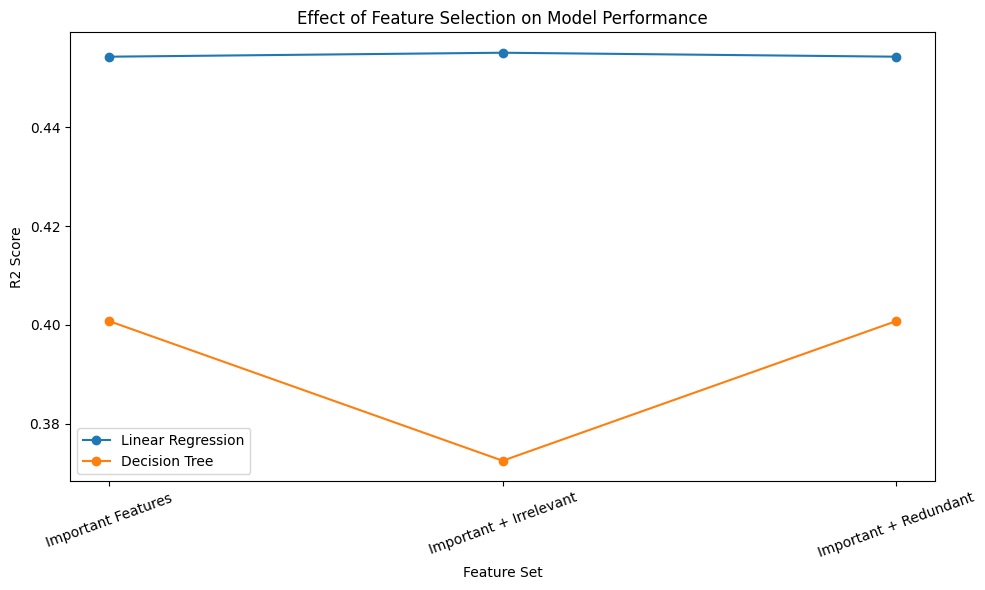

In [11]:
plt.figure(figsize=(10, 6))

for model in results_df["Model"].unique():

    model_data = results_df[
        results_df["Model"] == model
    ]

    plt.plot(
        model_data["Feature Set"],
        model_data["R2 Score"],
        marker="o",
        label=model
    )

plt.xlabel("Feature Set")
plt.ylabel("R2 Score")
plt.title("Effect of Feature Selection on Model Performance")

plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()

plt.show()

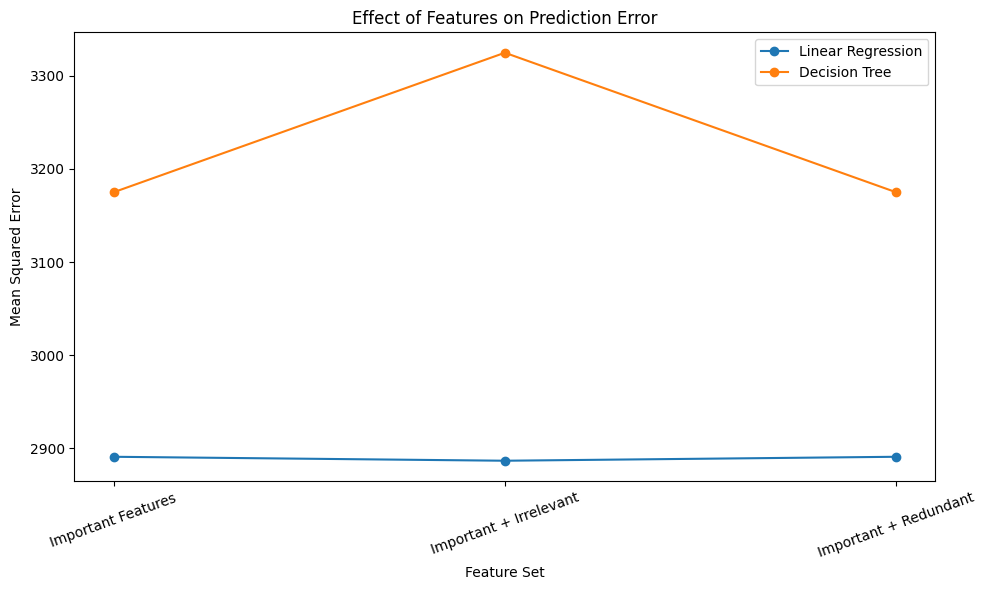

In [12]:
plt.figure(figsize=(10, 6))

for model in results_df["Model"].unique():

    model_data = results_df[
        results_df["Model"] == model
    ]

    plt.plot(
        model_data["Feature Set"],
        model_data["MSE"],
        marker="o",
        label=model
    )

plt.xlabel("Feature Set")
plt.ylabel("Mean Squared Error")
plt.title("Effect of Features on Prediction Error")

plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()

plt.show()